# Кластеризация абонентов сотового оператора

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

DATA = 'sber_data/'
activity = pd.read_csv(DATA + 'activity.csv', sep=';')
clients = pd.read_csv(DATA + 'clients.csv', sep=';')
categories = pd.read_csv(DATA + 'categories.csv', sep=';')
websites = pd.read_csv(DATA + 'websites.csv', sep=';')
regions = pd.read_csv(DATA + 'regions.csv', sep=';')

print(f"activity: {activity.shape}, clients: {clients.shape}")
print(f"categories: {categories.shape}, websites: {websites.shape}, regions: {regions.shape}")

activity: (1200000, 2), clients: (50000, 4)
categories: (30, 2), websites: (1251, 2), regions: (23, 2)


## Валидация данных

In [2]:
for name, df in [('activity', activity), ('clients', clients), ('categories', categories), ('websites', websites), ('regions', regions)]:
    print(f"\n=== {name} ===")
    print(f"Размер: {df.shape}, Дубликаты: {df.duplicated().sum()}")
    print(f"Пропуски:\n{df.isnull().sum()}")

print("\n=== Статистика clients ===")
print(clients.describe())
print(f"\nПол: {clients['gender'].value_counts().to_dict()}")
print(f"Возраст: {clients['age'].min()}-{clients['age'].max()}")


=== activity ===
Размер: (1200000, 2), Дубликаты: 90676
Пропуски:
client_id    0
website      0
dtype: int64

=== clients ===
Размер: (50000, 4), Дубликаты: 0
Пропуски:
id            0
age           0
gender       82
region_id     0
dtype: int64

=== categories ===
Размер: (30, 2), Дубликаты: 0
Пропуски:
id      0
name    0
dtype: int64

=== websites ===
Размер: (1251, 2), Дубликаты: 0
Пропуски:
website        0
category_id    0
dtype: int64

=== regions ===
Размер: (23, 2), Дубликаты: 0
Пропуски:
id      0
name    0
dtype: int64

=== Статистика clients ===
                age     region_id
count  50000.000000  50000.000000
mean      35.289600     11.269820
std       11.414935      6.386413
min       16.000000      1.000000
25%       27.000000      6.000000
50%       35.000000     12.000000
75%       43.000000     17.000000
max       80.000000     23.000000

Пол: {'F': 25997, 'M': 23921}
Возраст: 16-80


## Таблица соответствия сайтов и категорий

In [3]:
site_cats = (
    websites
    .merge(categories, left_on='category_id', right_on='id')
    [['website', 'name']]
    .copy()
)
site_cats['cat_num'] = site_cats.groupby('website').cumcount() + 1
site_cats = site_cats.rename(columns={'name': 'category'})

site_table = site_cats.pivot(index='website', columns='cat_num', values='category')
site_table.columns = [f'Категория {c}' for c in site_table.columns]
site_table = site_table.reset_index().rename(columns={'website': 'Сайт'})
site_table = site_table.sort_values('Сайт').reset_index(drop=True)

print(f"Всего сайтов: {len(site_table)}")
print(f"С одной категорией:  {site_table['Категория 2'].isna().sum()}")
print(f"С двумя категориями: {site_table['Категория 2'].notna().sum()}")

site_table_display = site_table.iloc[::10].fillna('')

display(
    site_table_display.style
    .set_caption("Сайты и их категории (первые 50)")
    .set_properties(**{'text-align': 'left', 'font-size': '12px'})
    .set_properties(subset=['Сайт'], **{'font-weight': 'bold', 'color': '#1a5276'})
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#1a2b45'),
                                      ('color', 'white'),
                                      ('font-size', '13px'),
                                      ('text-align', 'left'),
                                      ('padding', '6px 10px')]},
        {'selector': 'td', 'props': [('padding', '4px 10px')]},
    ])
    .hide(axis='index')
)

Всего сайтов: 1043
С одной категорией:  835
С двумя категориями: 208


Сайт,Категория 1,Категория 2
apteka-deal.online,Спорт и активный отдых,
aptekamarket.shop,Авто и мото,
avto-2456.io,Образование,
avtogrand.com,Обувь,Продукты питания
avtoroom.net,Путешествия и билеты,
baby-beauty.com,Образование,Развлечения
babydeal.ru,Спорт и активный отдых,
babypro87.net,Спорт и активный отдых,Финансы и страхование
bank-now56.ru,Ювелирные изделия,Недвижимость
bankcity.com,Спорт и активный отдых,


## Построение матрицы признаков

In [4]:

websites_map = websites[['website', 'category_id']].drop_duplicates()

# Если сайт относится к нескольким категориям, делим вклад визита равномерно: 1/k
site_cat_count = websites_map.groupby('website').size().rename('n_cat').reset_index()

merged = activity.merge(websites_map, on='website', how='left')
merged = merged.merge(site_cat_count, on='website', how='left')
merged = merged.merge(categories, left_on='category_id', right_on='id', how='left', suffixes=('', '_cat'))
merged = merged.dropna(subset=['name', 'n_cat'])
merged['weight'] = 1.0 / merged['n_cat']
merged['category_label'] = merged['name']

# Взвешенный pivot: сырые суммы весов по категориям
pivot_raw = merged.pivot_table(
    index='client_id',
    columns='category_label',
    values='weight',
    aggfunc='sum',
    fill_value=0
)
pivot_raw.columns.name = None

total_visits = pivot_raw.sum(axis=1)
low_threshold  = total_visits.quantile(0.10)
high_threshold = total_visits.quantile(0.90)
n_before = len(pivot_raw)
pivot_raw = pivot_raw[(total_visits > low_threshold) & (total_visits < high_threshold)]
n_after  = len(pivot_raw)
print(f"Удалено {n_before - n_after} пользователей ({(n_before-n_after)/n_before*100:.1f}%), осталось {n_after}")

# TF-IDF: down-weight популярные для всех категории, усиливает уникальные паттерны
from sklearn.feature_extraction.text import TfidfTransformer
tfidf = TfidfTransformer(norm='l1', use_idf=True, smooth_idf=True, sublinear_tf=True)
pivot_tfidf = tfidf.fit_transform(pivot_raw.values)
pivot = pd.DataFrame(pivot_tfidf.toarray(), index=pivot_raw.index, columns=pivot_raw.columns)

X_mixed_df      = pivot.copy()

Удалено 9350 пользователей (21.8%), осталось 33446


In [5]:
scaler = StandardScaler()
X = scaler.fit_transform(X_mixed_df)   # только поведение (30 TF-IDF признаков)

In [6]:
merged.head(5)


,client_id,website,category_id,n_cat,id,name,weight,category_label
0,35582702-dd5e-4198-b98f-2f8f6d1d70c6,fitpro.net,15.0,1.0,15.0,Мобильные приложения,1.0,Мобильные приложения
1,2ea5d5dd-6617-4500-9f50-87861d21d344,apteka-deal.online,6.0,1.0,6.0,Спорт и активный отдых,1.0,Спорт и активный отдых
2,4ae4a7d9-bafc-4a0f-b08e-8ddb2d57c3fe,avtostore.net,24.0,2.0,24.0,Социальные сети,0.5,Социальные сети
3,4ae4a7d9-bafc-4a0f-b08e-8ddb2d57c3fe,avtostore.net,3.0,2.0,3.0,Обувь,0.5,Обувь
4,547b51fb-58df-4b7b-b6f3-56846ba4e20c,avtokino.shop,8.0,1.0,8.0,Стройка и ремонт,1.0,Стройка и ремонт


## Распределение категорий по демографии

Графики ниже показывают распределение посещаемости категорий в разрезе:
- возраста,
- пола,
- региона.

Используются взвешенные посещения (`weight`) и категории.

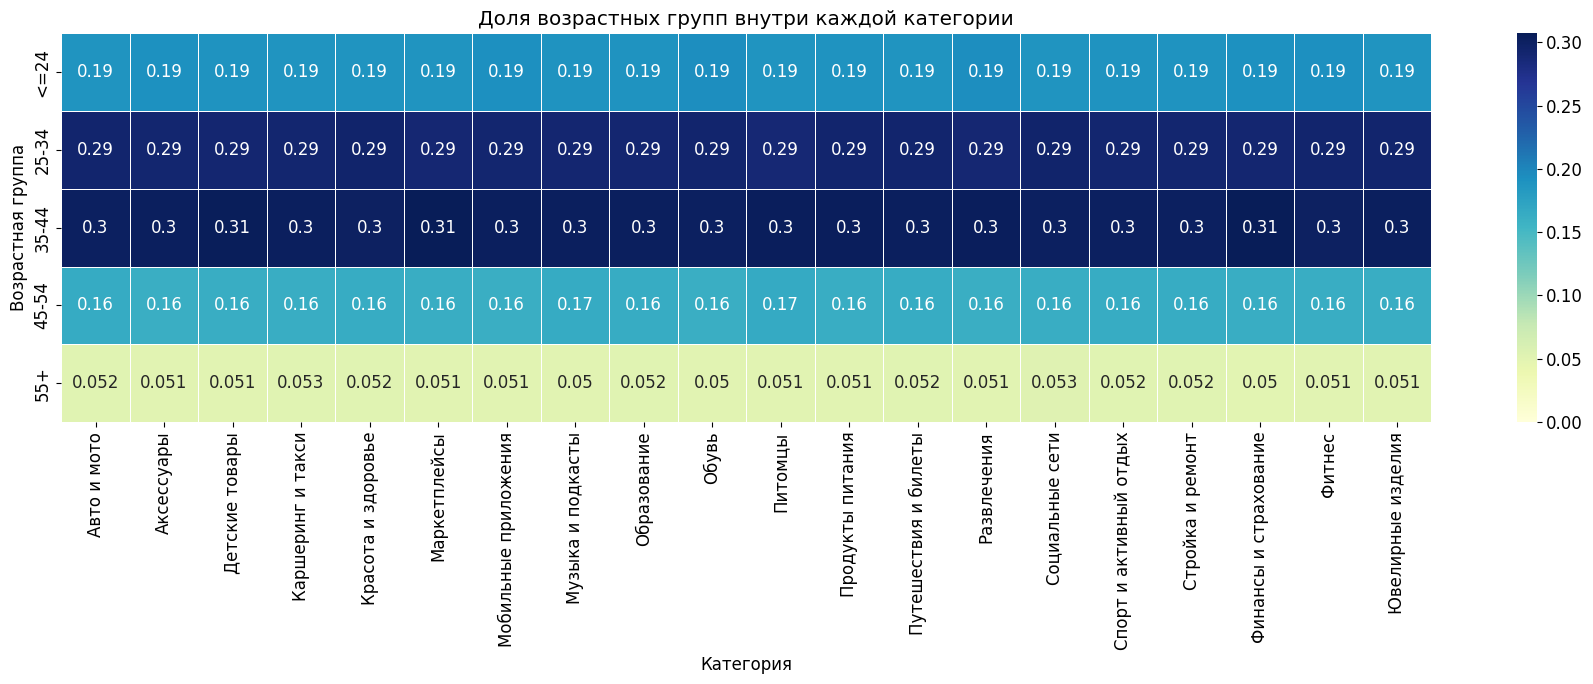

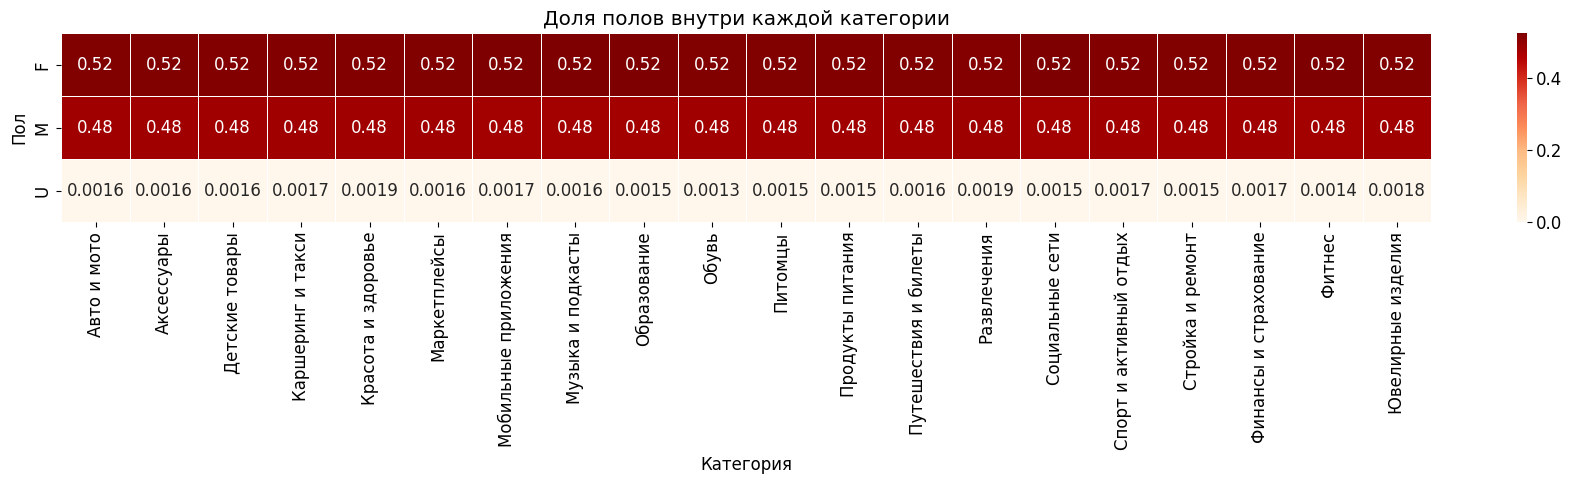

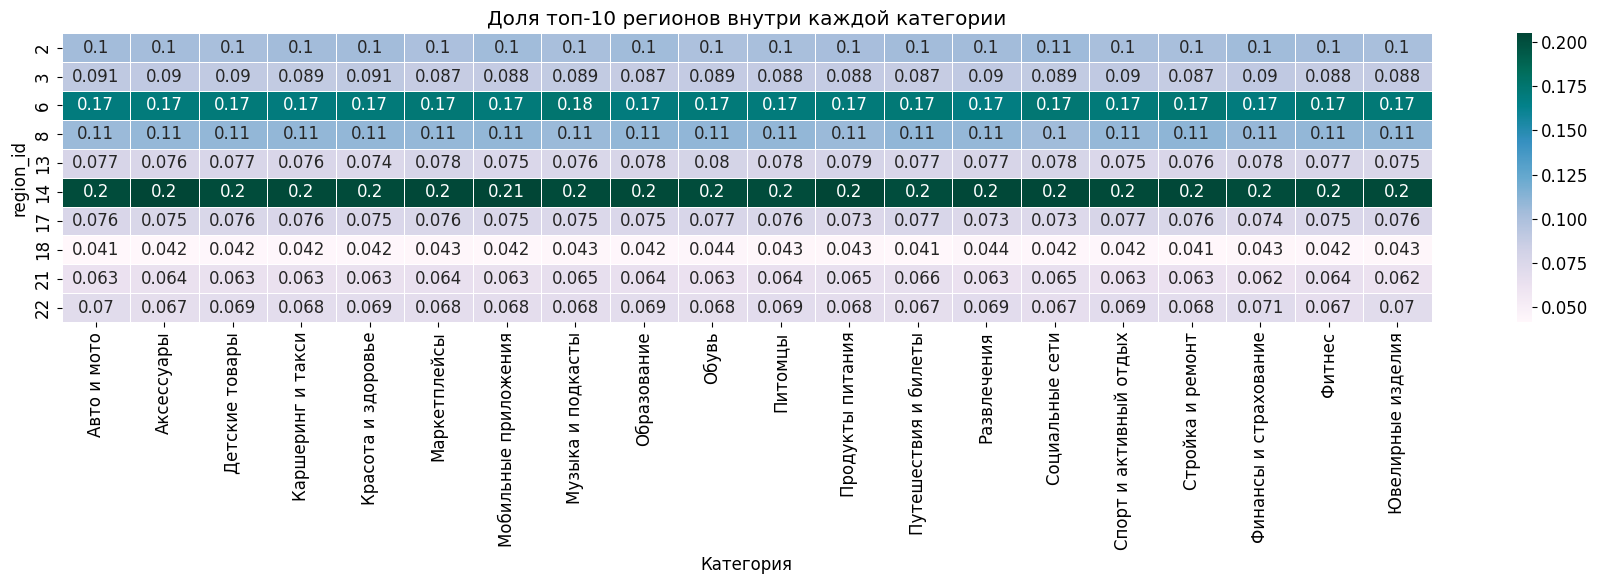

Топ категорий в анализе: ['Спорт и активный отдых', 'Ювелирные изделия', 'Каршеринг и такси', 'Аксессуары', 'Стройка и ремонт', 'Образование', 'Мобильные приложения', 'Питомцы', 'Детские товары', 'Путешествия и билеты', 'Красота и здоровье', 'Маркетплейсы', 'Авто и мото', 'Музыка и подкасты', 'Обувь', 'Социальные сети', 'Продукты питания', 'Развлечения', 'Финансы и страхование', 'Фитнес']


In [9]:
clients_demo = clients.rename(columns={'id': 'client_id'})[['client_id', 'age', 'gender', 'region_id']].copy()
clients_demo['gender'] = clients_demo['gender'].fillna('U')

demo_visits = merged[['client_id', 'category_label', 'weight']].merge(clients_demo, on='client_id', how='left')
demo_visits = demo_visits.dropna(subset=['category_label', 'weight'])

# Возрастные группы
age_bins   = [0, 24, 34, 44, 54, 120]
age_labels = ['<=24', '25-34', '35-44', '45-54', '55+']
demo_visits['age_group'] = pd.cut(demo_visits['age'], bins=age_bins, labels=age_labels, right=True)

# Топ-20 категорий по суммарному числу посещений
top_n = 20
top_categories = (demo_visits.groupby('category_label')['weight'].sum()
                  .sort_values(ascending=False).head(top_n).index)

# Доля возрастных групп внутри каждой категории
age_raw = (
    demo_visits[demo_visits['category_label'].isin(top_categories)]
    .pivot_table(index='age_group', columns='category_label',
                 values='weight', aggfunc='sum', fill_value=0)
)
age_col_norm = age_raw.div(age_raw.sum(axis=0), axis=1)

plt.figure(figsize=(18, 7))
sns.heatmap(age_col_norm, cmap='YlGnBu', annot=True, fmt='.2',
            linewidths=0.5, vmin=0)
plt.title('Доля возрастных групп внутри каждой категории')
plt.xlabel('Категория')
plt.ylabel('Возрастная группа')
plt.tight_layout()
plt.show()

# Доля полов внутри каждой категории
gender_raw = (
    demo_visits[demo_visits['category_label'].isin(top_categories)]
    .pivot_table(index='gender', columns='category_label',
                 values='weight', aggfunc='sum', fill_value=0)
)
gender_col_norm = gender_raw.div(gender_raw.sum(axis=0), axis=1)

plt.figure(figsize=(18, 5))
sns.heatmap(gender_col_norm, cmap='OrRd', annot=True, fmt='.2',
            linewidths=0.5, vmin=0)
plt.title('Доля полов внутри каждой категории')
plt.xlabel('Категория')
plt.ylabel('Пол')
plt.tight_layout()
plt.show()

# Доля топ-10 регионов внутри каждой категории
top_regions = (demo_visits.groupby('region_id')['weight'].sum()
               .sort_values(ascending=False).head(10).index)
region_raw = (
    demo_visits[
        demo_visits['region_id'].isin(top_regions)
        & demo_visits['category_label'].isin(top_categories)
    ]
    .pivot_table(index='region_id', columns='category_label',
                 values='weight', aggfunc='sum', fill_value=0)
)
region_col_norm = region_raw.div(region_raw.sum(axis=0), axis=1)

plt.figure(figsize=(18, 6))
sns.heatmap(region_col_norm, cmap='PuBuGn', annot=True, fmt='.2',
            linewidths=0.4)
plt.title('Доля топ-10 регионов внутри каждой категории')
plt.xlabel('Категория')
plt.ylabel('region_id')
plt.tight_layout()
plt.show()

print(f"Топ категорий в анализе: {list(top_categories)}")

## KMeans кластеризация

### Подбор количества кластеров

PCA 15 компонент объясняет 58.6% дисперсии
Silhouette по всем k:
  k= 2: silhouette=0.1294  inertia=527364
  k= 3: silhouette=0.0417  inertia=507300
  k= 4: silhouette=0.0384  inertia=491815
  k= 5: silhouette=0.0399  inertia=478719
  k= 6: silhouette=0.0384  inertia=467923
  k= 7: silhouette=0.0377  inertia=458615
  k= 8: silhouette=0.0388  inertia=450141
  k= 9: silhouette=0.0393  inertia=442831
  k=10: silhouette=0.0399  inertia=436275


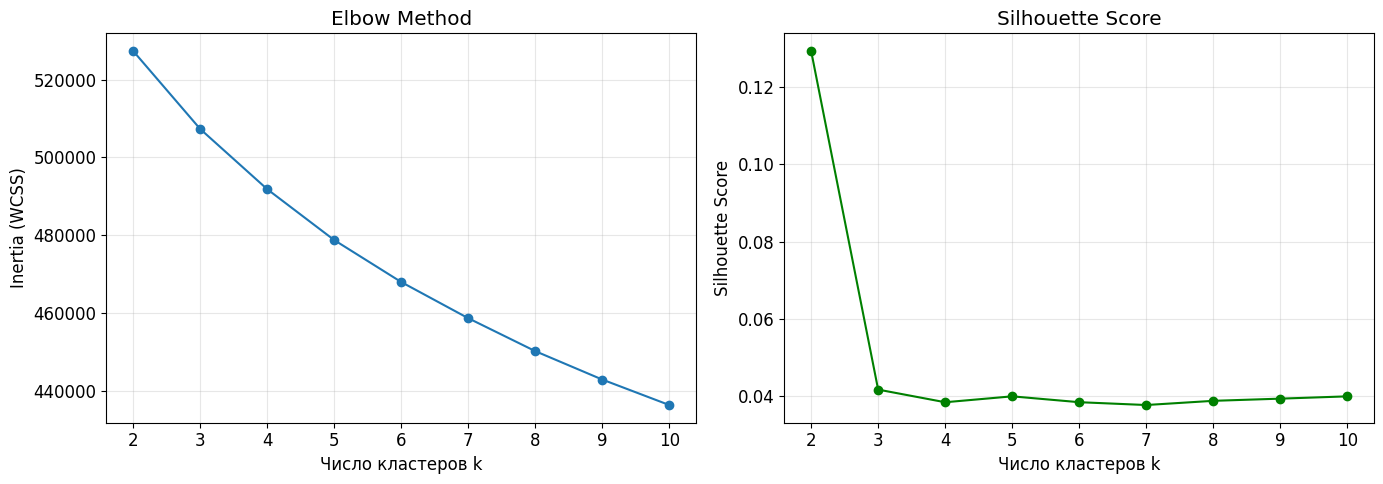


Лучшее k (с ограничением k≥5): 5


In [130]:
pca_km = PCA(n_components=15, random_state=42)
X_pca = pca_km.fit_transform(X)
explained_var = pca_km.explained_variance_ratio_.cumsum()
print(f"PCA 15 компонент объясняет {explained_var[-1]:.1%} дисперсии")

# Elbow + Silhouette для выбора k
k_range = range(2, 11)
inertias, silhouettes = [], []
for k in k_range:
    km_tmp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_tmp = km_tmp.fit_predict(X_pca)
    inertias.append(km_tmp.inertia_)
    silhouettes.append(
        silhouette_score(X_pca, labels_tmp, sample_size=min(5000, len(labels_tmp)), random_state=42)
    )

print("Silhouette по всем k:")
for k, sil, ine in zip(k_range, silhouettes, inertias):
    print(f"  k={k:2d}: silhouette={sil:.4f}  inertia={ine:.0f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), inertias, 'o-')
axes[0].set_xlabel('Число кластеров k')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method')
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(k_range), silhouettes, 'o-', color='green')
axes[1].set_xlabel('Число кластеров k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

MIN_K = 5
silhouettes_clipped = [s if k >= MIN_K else -np.inf
                       for k, s in zip(k_range, silhouettes)]
best_k = list(k_range)[int(np.argmax(silhouettes_clipped))]
print(f"\nЛучшее k (с ограничением k≥{MIN_K}): {best_k}")



### Кластеризация KMeans


Распределение по кластерам:
cluster
0    5063
1    9068
2    6492
3    6562
4    6261
Name: count, dtype: int64


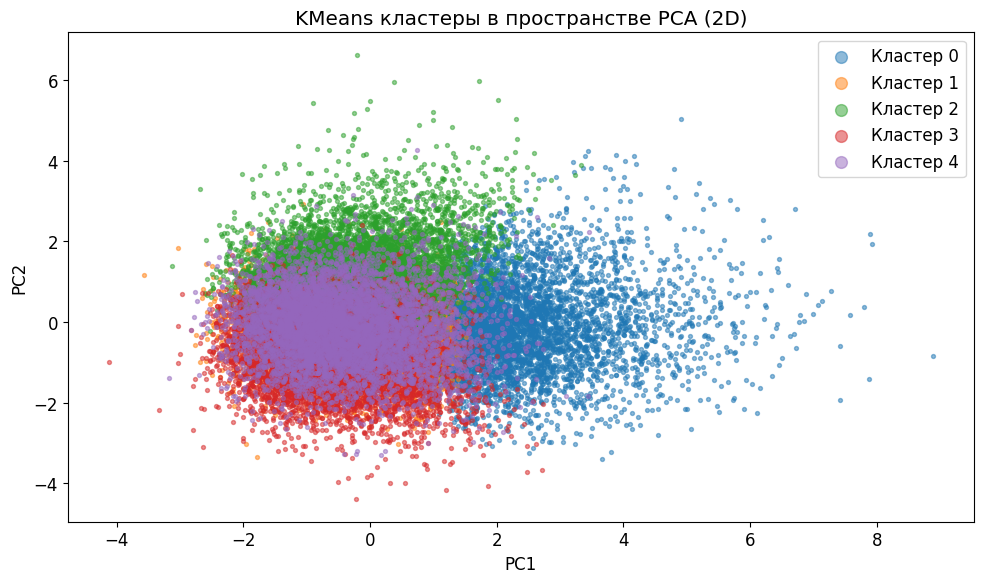

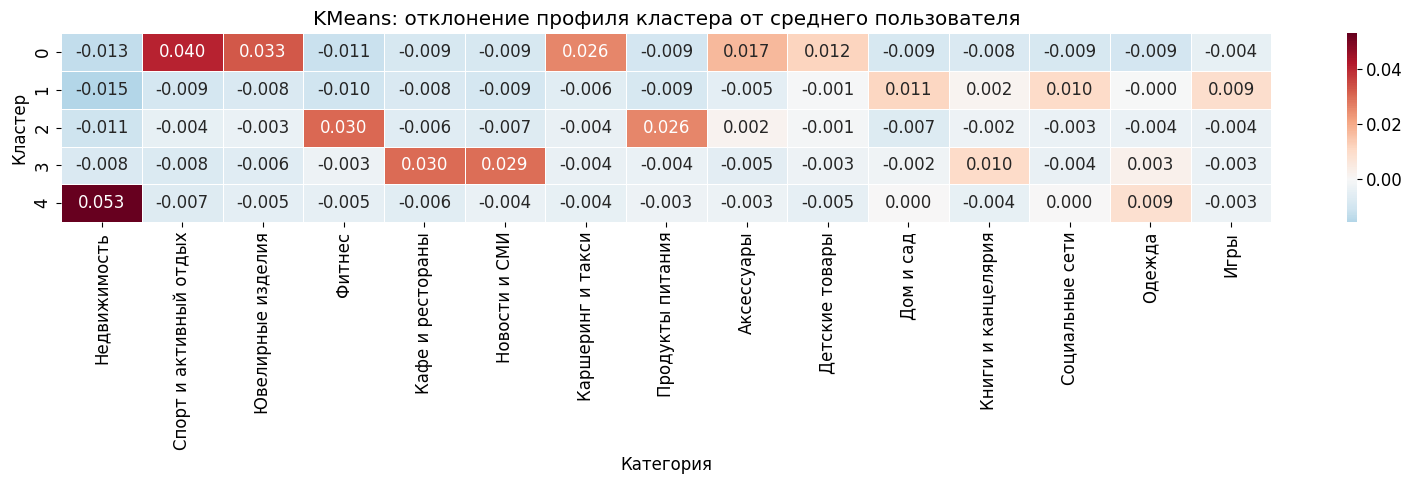


── Кластер 0 (5063 абонентов) ──
Повышенный интерес (vs среднее):
Спорт и активный отдых    0.0403
Ювелирные изделия         0.0326
Каршеринг и такси         0.0257
Аксессуары                0.0171
Детские товары            0.0118
Пониженный интерес (vs среднее):
Недвижимость   -0.0129
Фитнес         -0.0114
Одежда         -0.0095

── Кластер 1 (9068 абонентов) ──
Повышенный интерес (vs среднее):
Дом и сад          0.0112
Социальные сети    0.0099
Игры               0.0093
Маркетплейсы       0.0074
Развлечения        0.0060
Пониженный интерес (vs среднее):
Недвижимость             -0.0154
Фитнес                   -0.0101
Спорт и активный отдых   -0.0092

── Кластер 2 (6492 абонентов) ──
Повышенный интерес (vs среднее):
Фитнес                0.0302
Продукты питания      0.0256
Обувь                 0.0046
Медицина и аптеки     0.0036
Красота и здоровье    0.0028
Пониженный интерес (vs среднее):
Недвижимость    -0.0111
Дом и сад       -0.0070
Новости и СМИ   -0.0067

── Кластер 3 (6562 

In [131]:
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
pivot['cluster'] = kmeans_final.fit_predict(X_pca)
print(f"\nРаспределение по кластерам:\n{pivot['cluster'].value_counts().sort_index()}")

# Визуализация в 2D PCA
pca_2d_km = PCA(n_components=2, random_state=42)
X_2d = pca_2d_km.fit_transform(X_pca)
plt.figure(figsize=(10, 6))
for cl in sorted(pivot['cluster'].unique()):
    mask = pivot['cluster'] == cl
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], s=8, alpha=0.5, label=f'Кластер {cl}')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('KMeans кластеры в пространстве PCA (2D)')
plt.legend(markerscale=3)
plt.tight_layout()
plt.show()

# Отклолнение от среднего пользователя
cat_cols_km = [c for c in pivot.columns if c not in ['cluster', 'cluster_hdbscan']
               and np.issubdtype(pivot[c].dtype, np.number)]
cluster_profiles = pivot.groupby('cluster')[cat_cols_km].mean()
global_mean = pivot[cat_cols_km].mean()
cluster_deviation = cluster_profiles - global_mean

# Топ признаков с наибольшим межкластерным разбросом
top_features = cluster_deviation.abs().max(axis=0).sort_values(ascending=False).head(15).index

plt.figure(figsize=(16, max(4, best_k)))
sns.heatmap(
    cluster_deviation[top_features],
    cmap='RdBu_r', center=0, annot=True, fmt='.3f', linewidths=0.5
)
plt.title('KMeans: отклонение профиля кластера от среднего пользователя')
plt.xlabel('Категория')
plt.ylabel('Кластер')
plt.tight_layout()
plt.show()

for cl in sorted(cluster_profiles.index):
    n = (pivot['cluster'] == cl).sum()
    top5 = cluster_deviation.loc[cl].sort_values(ascending=False).head(5)
    bot3 = cluster_deviation.loc[cl].sort_values(ascending=True).head(3)
    print(f"\n── Кластер {cl} ({n} абонентов) ──")
    print("Повышенный интерес (vs среднее):")
    print(top5.round(4).to_string())
    print("Пониженный интерес (vs среднее):")
    print(bot3.round(4).to_string())

## Демографические профили кластеров (KMeans)

Для каждого кластера: распределение возраста, пола и топ-регионов.

── Сводная таблица демографии по кластерам ──


,Абонентов,Возраст (медиана),Возраст (mean±std),"Женщины, %","Мужчины, %",Топ-регион
Кластер,,,,,,
0,5063,35.0,35.3 ± 11.4,51.3,48.4,Саратовская область
1,9068,35.0,35.4 ± 11.2,52.3,47.6,Саратовская область
2,6492,35.0,35.3 ± 11.4,52.7,47.2,Саратовская область
3,6562,35.0,35.4 ± 11.5,51.6,48.3,Саратовская область
4,6261,35.0,35.2 ± 11.4,52.5,47.3,Саратовская область


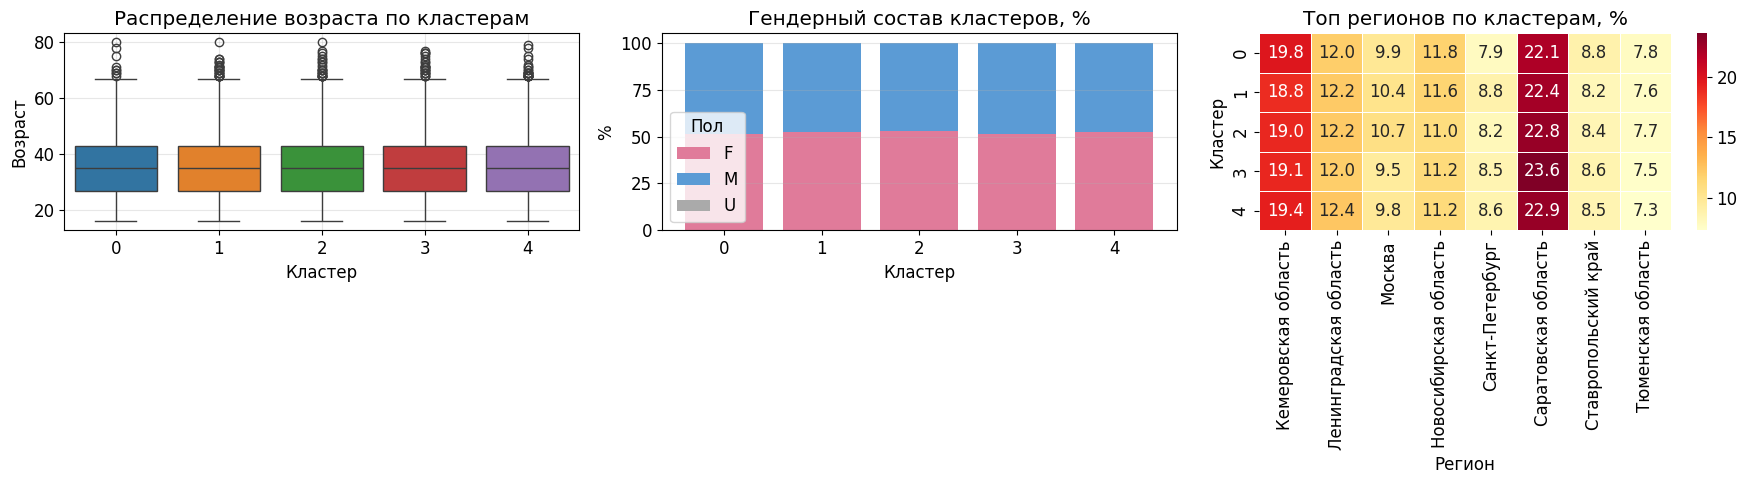

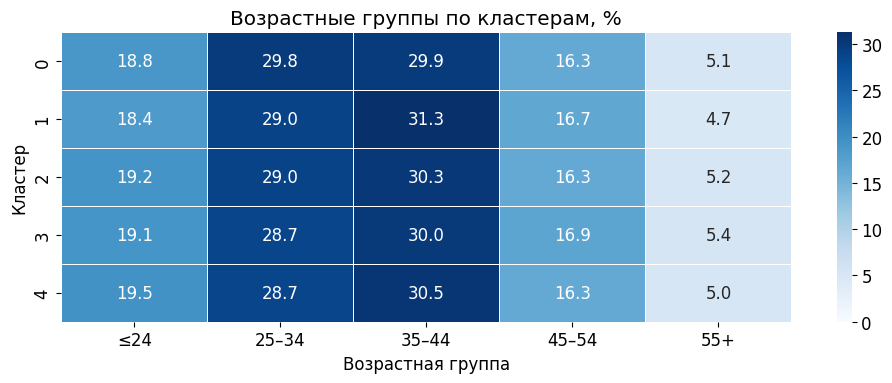

In [132]:
# ── Демографические профили кластеров KMeans ─────────────────────────────────

clients_demo = clients.rename(columns={'id': 'client_id'})[
    ['client_id', 'age', 'gender', 'region_id']
].copy()
clients_demo['gender'] = clients_demo['gender'].fillna('U')

# Присоединяем метки кластеров к демографии
cluster_demo = (
    pivot[['cluster']]
    .reset_index()
    .merge(clients_demo, on='client_id', how='left')
    .merge(regions.rename(columns={'id': 'region_id', 'name': 'region_name'}),
            on='region_id', how='left')
)
cluster_demo['age'] = cluster_demo['age'].fillna(cluster_demo['age'].median())
n_clusters_km = cluster_demo['cluster'].nunique()
palette_km = sns.color_palette('tab10', n_colors=n_clusters_km)

# ── 1. Сводная таблица ──────────────────────────────────────────────────
summary_rows = []
for cl in sorted(cluster_demo['cluster'].unique()):
    sub = cluster_demo[cluster_demo['cluster'] == cl]
    top_region = sub['region_name'].value_counts().idxmax() if sub['region_name'].notna().any() else '—'
    pct_female = (sub['gender'] == 'F').mean() * 100
    pct_male   = (sub['gender'] == 'M').mean() * 100
    summary_rows.append({
        'Кластер':        cl,
        'Абонентов':      len(sub),
        'Возраст (медиана)': sub['age'].median(),
        'Возраст (mean±std)': f"{sub['age'].mean():.1f} ± {sub['age'].std():.1f}",
        'Женщины, %':     f"{pct_female:.1f}",
        'Мужчины, %':     f"{pct_male:.1f}",
        'Топ-регион':     top_region,
    })
summary_df = pd.DataFrame(summary_rows).set_index('Кластер')
print("── Сводная таблица демографии по кластерам ──")
display(summary_df)

# ── 2. Возрастные ящики (box plot) ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

order = sorted(cluster_demo['cluster'].unique())
sns.boxplot(
    data=cluster_demo, x='cluster', y='age', order=order,
    palette=palette_km, ax=axes[0]
)
axes[0].set_title('Распределение возраста по кластерам')
axes[0].set_xlabel('Кластер')
axes[0].set_ylabel('Возраст')
axes[0].grid(True, alpha=0.3)

# ── 3. Гендерный состав (stacked bar) ───────────────────────────────────
gender_dist = (
    cluster_demo.groupby(['cluster', 'gender'])
    .size()
    .unstack(fill_value=0)
    .reindex(order)
)
gender_pct = gender_dist.div(gender_dist.sum(axis=1), axis=0) * 100
gender_colors = {'F': '#e07b9a', 'M': '#5b9bd5', 'U': '#aaaaaa'}
bottom = pd.Series(0, index=gender_pct.index)
for g in gender_pct.columns:
    color = gender_colors.get(g, '#cccccc')
    axes[1].bar(gender_pct.index.astype(str), gender_pct[g], bottom=bottom, label=g, color=color)
    bottom = bottom + gender_pct[g]
axes[1].set_title('Гендерный состав кластеров, %')
axes[1].set_xlabel('Кластер')
axes[1].set_ylabel('%')
axes[1].legend(title='Пол')
axes[1].grid(True, alpha=0.3, axis='y')

# ── 4. Топ-5 регионов (heatmap долей) ───────────────────────────────────
top_regions = (
    cluster_demo['region_name']
    .value_counts()
    .head(8)
    .index
)
region_dist = (
    cluster_demo[cluster_demo['region_name'].isin(top_regions)]
    .groupby(['cluster', 'region_name'])
    .size()
    .unstack(fill_value=0)
    .reindex(order)
)
region_pct = region_dist.div(region_dist.sum(axis=1), axis=0) * 100
sns.heatmap(
    region_pct, cmap='YlOrRd', annot=True, fmt='.1f',
    linewidths=0.5, ax=axes[2]
)
axes[2].set_title('Топ регионов по кластерам, %')
axes[2].set_xlabel('Регион')
axes[2].set_ylabel('Кластер')

plt.tight_layout()
plt.show()

# ── 5. Возрастные группы (heatmap долей) ────────────────────────────────
age_bins   = [0, 24, 34, 44, 54, 120]
age_labels = ['≤24', '25–34', '35–44', '45–54', '55+']
cluster_demo['age_group'] = pd.cut(
    cluster_demo['age'], bins=age_bins, labels=age_labels, right=True
)
age_group_dist = (
    cluster_demo.groupby(['cluster', 'age_group'], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(order)
)
age_group_pct = age_group_dist.div(age_group_dist.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10, max(3, n_clusters_km * 0.6 + 1)))
sns.heatmap(
    age_group_pct, cmap='Blues', annot=True, fmt='.1f',
    linewidths=0.5, vmin=0
)
plt.title('Возрастные группы по кластерам, %')
plt.xlabel('Возрастная группа')
plt.ylabel('Кластер')
plt.tight_layout()
plt.show()

## Кластеризация HDBSCAN + UMAP/PCA

In [133]:
# HDBSCAN + UMAP/PCA: подготовка признаков и обучение
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

import umap.umap_ as umap
import hdbscan

interest_features = pivot.drop(columns=['cluster', 'cluster_hdbscan'], errors='ignore').copy()
X_all = interest_features.copy()
print(f"HDBSCAN: только поведенческие признаки ({X_all.shape[1]} категорий)")

# Нормализация
scaler_hdb = StandardScaler()
X_scaled = scaler_hdb.fit_transform(X_all)

# PCA
pca_hdb = PCA(n_components=min(15, X_scaled.shape[1]), random_state=42)
X_pca_hdb = pca_hdb.fit_transform(X_scaled)

# UMAP 10D (пространство для HDBSCAN)
umap_10d = umap.UMAP(
    n_components=10,
    n_neighbors=30,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)
X_umap_10d = umap_10d.fit_transform(X_scaled)

# HDBSCAN
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=300,
    min_samples=30,
    metric='euclidean',
    cluster_selection_method='eom'
)
labels_hdb = clusterer.fit_predict(X_umap_10d)

pivot['cluster_hdbscan'] = labels_hdb

# Сводка
n_clusters = len(set(labels_hdb)) - (1 if -1 in labels_hdb else 0)
noise_share = (labels_hdb == -1).mean()

print(f"HDBSCAN: найдено кластеров = {n_clusters}")
print(f"Доля шума (-1): {noise_share:.1%}")

mask = labels_hdb != -1
if n_clusters > 1 and mask.sum() > 0 and len(np.unique(labels_hdb[mask])) > 1:
    sil = silhouette_score(X_umap_10d[mask], labels_hdb[mask])
    ch = calinski_harabasz_score(X_umap_10d[mask], labels_hdb[mask])
    db = davies_bouldin_score(X_umap_10d[mask], labels_hdb[mask])
    print(f"Silhouette (без шума): {sil:.3f}")
    print(f"Calinski-Harabasz (без шума): {ch:.1f}")
    print(f"Davies-Bouldin (без шума): {db:.3f}")
else:
    print("Недостаточно кластеров для корректного расчета метрик.")

pd.Series(labels_hdb).value_counts().sort_index().head(20)

HDBSCAN: только поведенческие признаки (29 категорий)
HDBSCAN: найдено кластеров = 15
Доля шума (-1): 39.4%
Silhouette (без шума): 0.437
Calinski-Harabasz (без шума): 9427.1
Davies-Bouldin (без шума): 0.821


-1     13170
 0      6285
 1      1903
 2      2262
 3       652
 4       600
 5       877
 6       475
 7      2040
 8       881
 9       475
 10      367
 11     1390
 12      447
 13     1305
 14      317
Name: count, dtype: int64

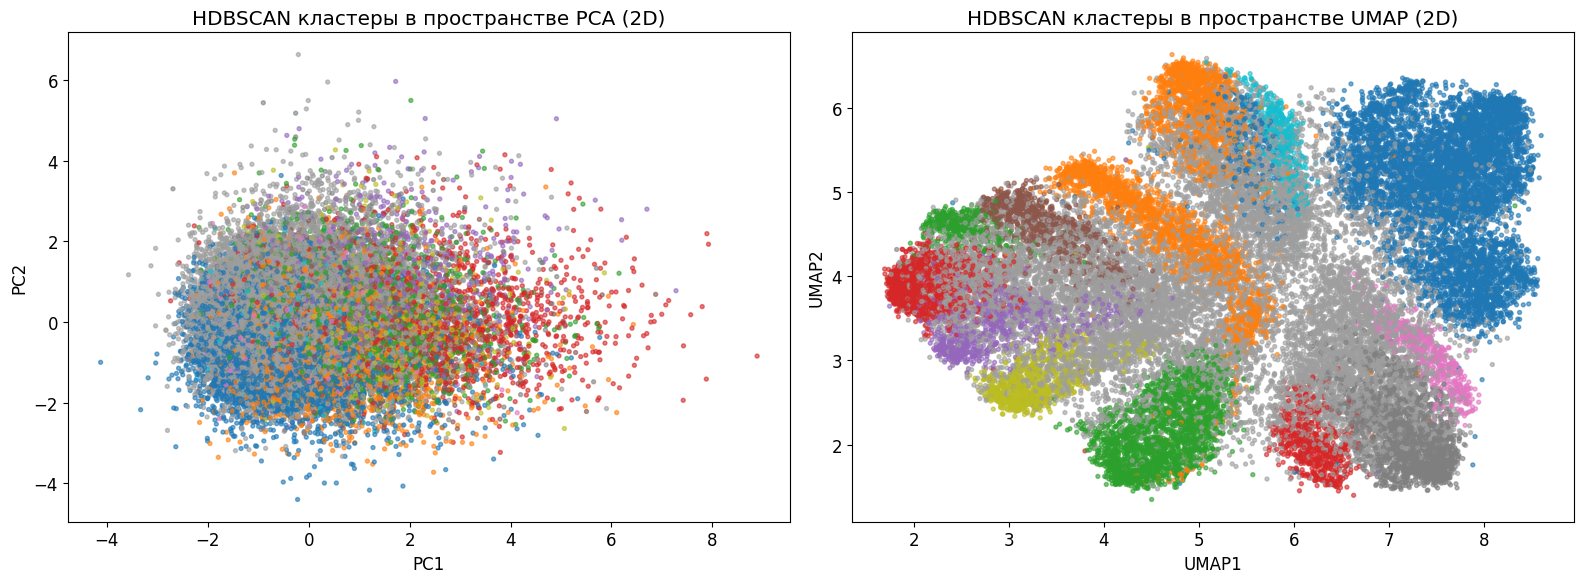

Размеры кластеров HDBSCAN (включая шум -1):


cluster_hdbscan
-1     13170
 0      6285
 1      1903
 2      2262
 3       652
 4       600
 5       877
 6       475
 7      2040
 8       881
 9       475
 10      367
 11     1390
 12      447
 13     1305
 14      317
Name: count, dtype: int64

In [134]:
# Визуализация кластеров HDBSCAN в пространствах PCA и UMAP
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

umap_2d = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)
X_umap_2d = umap_2d.fit_transform(X_scaled)

labels = pivot['cluster_hdbscan'].values
unique_labels = sorted(np.unique(labels))

# Цвета: шум (-1) выделяем серым
palette = sns.color_palette('tab10', n_colors=max(len(unique_labels), 3))
color_map = {-1: '#9e9e9e'}
regular_labels = [lab for lab in unique_labels if lab != -1]
for i, lab in enumerate(regular_labels):
    color_map[lab] = palette[i % len(palette)]
point_colors = [color_map[lab] for lab in labels]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=point_colors, s=8, alpha=0.6)
axes[0].set_title('HDBSCAN кластеры в пространстве PCA (2D)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

axes[1].scatter(X_umap_2d[:, 0], X_umap_2d[:, 1], c=point_colors, s=8, alpha=0.6)
axes[1].set_title('HDBSCAN кластеры в пространстве UMAP (2D)')
axes[1].set_xlabel('UMAP1')
axes[1].set_ylabel('UMAP2')

plt.tight_layout()
plt.show()

print('Размеры кластеров HDBSCAN (включая шум -1):')
display(pivot['cluster_hdbscan'].value_counts().sort_index())

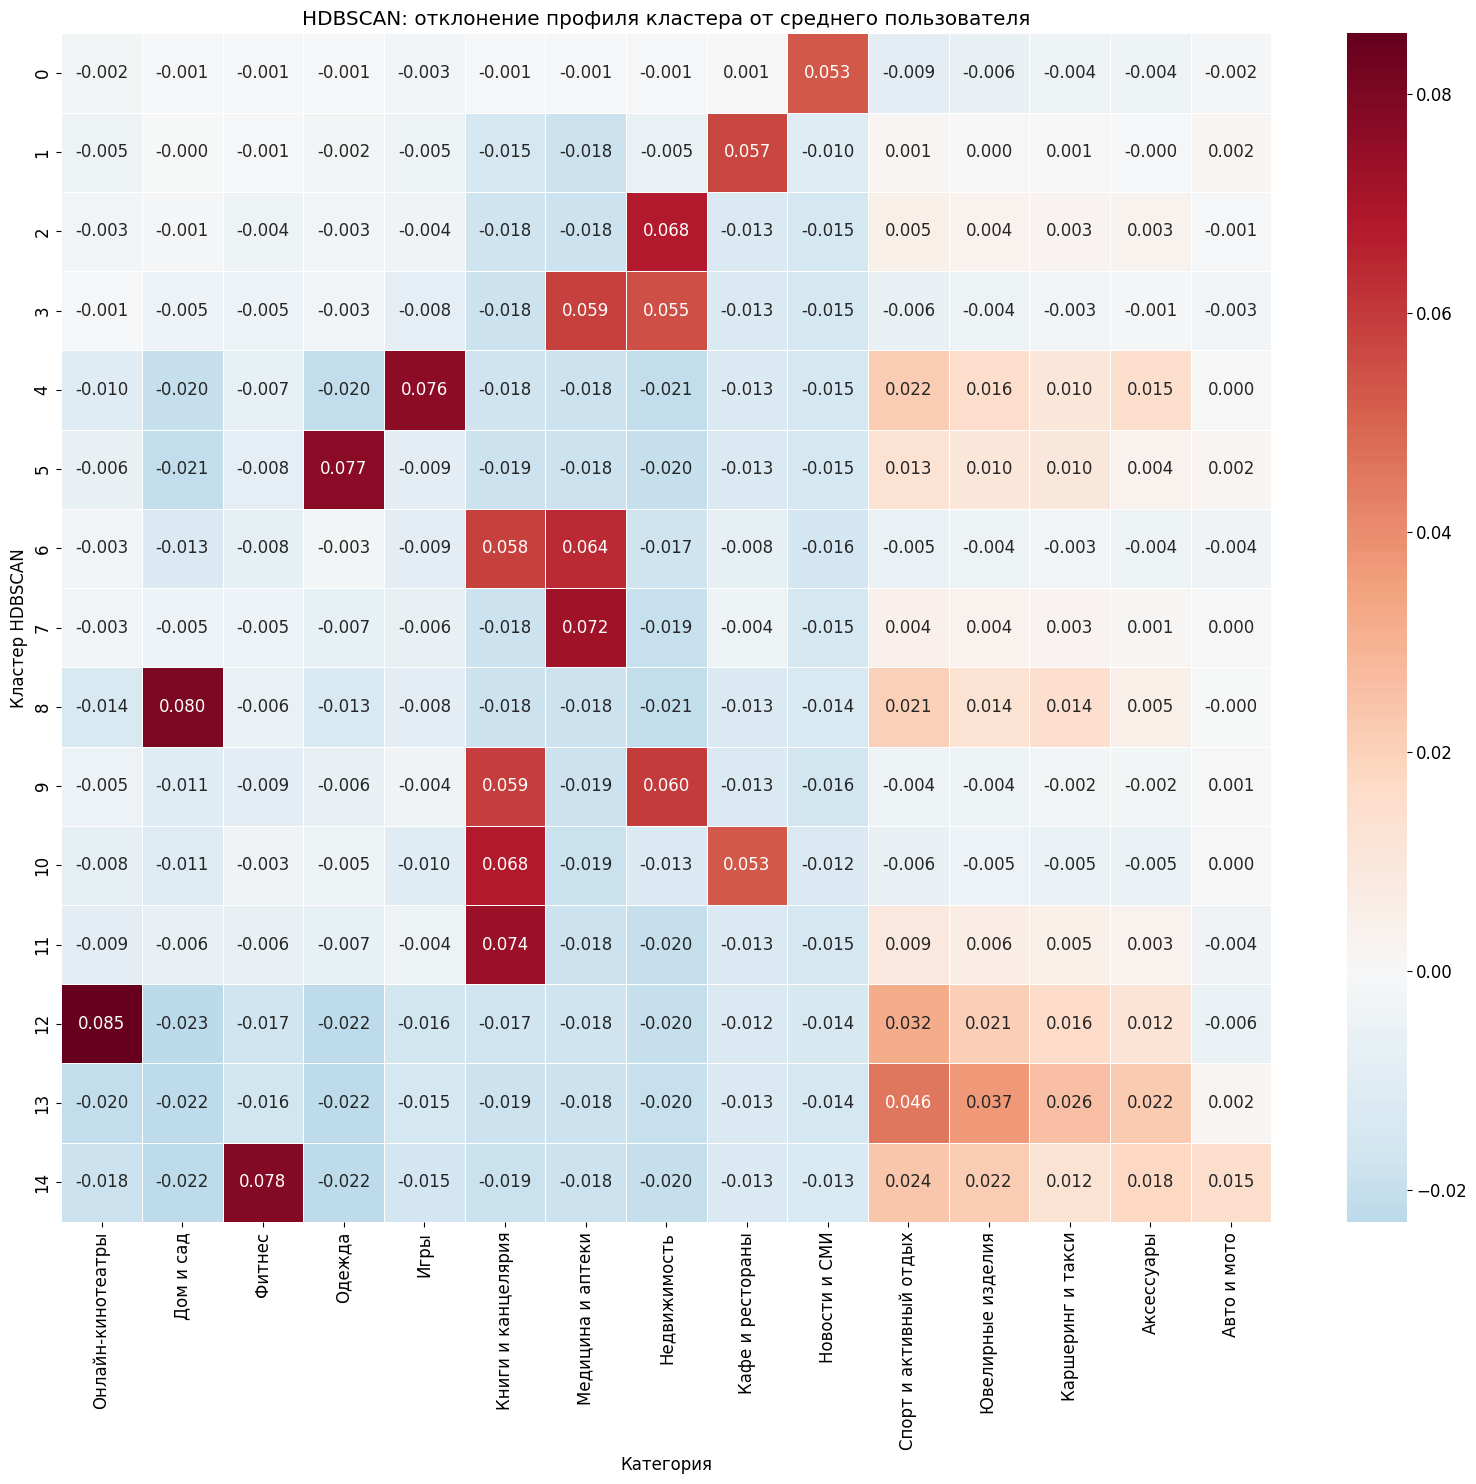


── Кластер HDBSCAN 0 (6285 абонентов) ──
Повышенный интерес (vs среднее):
Новости и СМИ        0.0528
Кафе и рестораны     0.0005
Фитнес              -0.0006
Обувь               -0.0006
Медицина и аптеки   -0.0007
Пониженный интерес (vs среднее):
Спорт и активный отдых   -0.0086
Ювелирные изделия        -0.0061
Каршеринг и такси        -0.0042

── Кластер HDBSCAN 1 (1903 абонентов) ──
Повышенный интерес (vs среднее):
Кафе и рестораны         0.0568
Финансы и страхование    0.0022
Авто и мото              0.0018
Маркетплейсы             0.0017
Стройка и ремонт         0.0014
Пониженный интерес (vs среднее):
Медицина и аптеки    -0.0181
Книги и канцелярия   -0.0151
Новости и СМИ        -0.0099

── Кластер HDBSCAN 2 (2262 абонентов) ──
Повышенный интерес (vs среднее):
Недвижимость              0.0679
Спорт и активный отдых    0.0049
Ювелирные изделия         0.0039
Аксессуары                0.0031
Каршеринг и такси         0.0025
Пониженный интерес (vs среднее):
Медицина и аптеки    -0.0

In [135]:
# Профили кластеров HDBSCAN по интересам
cat_cols_hdb = [
    c for c in pivot.columns
    if c not in ['cluster', 'cluster_hdbscan'] and np.issubdtype(pivot[c].dtype, np.number)
]

hdb_data = pivot[pivot['cluster_hdbscan'] != -1]
hdb_profiles = hdb_data.groupby('cluster_hdbscan')[cat_cols_hdb].mean()

if len(hdb_profiles) > 0 and len(cat_cols_hdb) > 0:

    global_mean_hdb = pivot[cat_cols_hdb].mean()
    hdb_deviation = hdb_profiles - global_mean_hdb

    top_cols = hdb_deviation.abs().max(axis=0).sort_values(ascending=False).head(15).index

    plt.figure(figsize=(16, max(5, len(hdb_profiles))))
    sns.heatmap(
        hdb_deviation[top_cols],
        cmap='RdBu_r', center=0, annot=True, fmt='.3f', linewidths=0.5
    )
    plt.title('HDBSCAN: отклонение профиля кластера от среднего пользователя')
    plt.xlabel('Категория')
    plt.ylabel('Кластер HDBSCAN')
    plt.tight_layout()
    plt.show()

    for cl in sorted(hdb_profiles.index):
        n = (pivot['cluster_hdbscan'] == cl).sum()
        top5 = hdb_deviation.loc[cl].sort_values(ascending=False).head(5)
        bot3 = hdb_deviation.loc[cl].sort_values(ascending=True).head(3)
        print(f"\n── Кластер HDBSCAN {cl} ({n} абонентов) ──")
        print("Повышенный интерес (vs среднее):")
        print(top5.round(4).to_string())
        print("Пониженный интерес (vs среднее):")
        print(bot3.round(4).to_string())
else:
    print('Нет кластеров без шума или нет числовых категориальных признаков для профилирования.')

## Демографические профили кластеров (HDBSCAN)

Аналогичный анализ для HDBSCAN-кластеров (без шумовых точек -1).

Блок ниже помогает понять, есть ли в данных выраженная кластерная структура:
- размер и баланс кластеров,
- метрики разделимости,
- расстояния между центроидами,
- признаки, которые больше всего отличают кластеры.

── Сводная таблица демографии HDBSCAN-кластеров ──


,Абонентов,Возраст (медиана),Возраст (mean±std),"Женщины, %","Мужчины, %",Топ-регион
Кластер,,,,,,
0,6285,35.0,35.5 ± 11.3,52.1,47.7,Саратовская область
1,1903,35.0,35.2 ± 11.5,52.5,47.3,Саратовская область
2,2262,35.0,34.9 ± 11.4,52.2,47.8,Саратовская область
3,652,35.0,34.6 ± 10.8,54.9,44.8,Саратовская область
4,600,35.0,34.8 ± 10.7,51.5,48.2,Саратовская область
5,877,35.0,34.8 ± 11.6,52.2,47.5,Саратовская область
6,475,35.0,36.0 ± 11.5,48.8,50.5,Саратовская область
7,2040,35.0,35.3 ± 11.3,53.5,46.4,Саратовская область
8,881,35.0,35.0 ± 11.4,50.6,49.4,Саратовская область


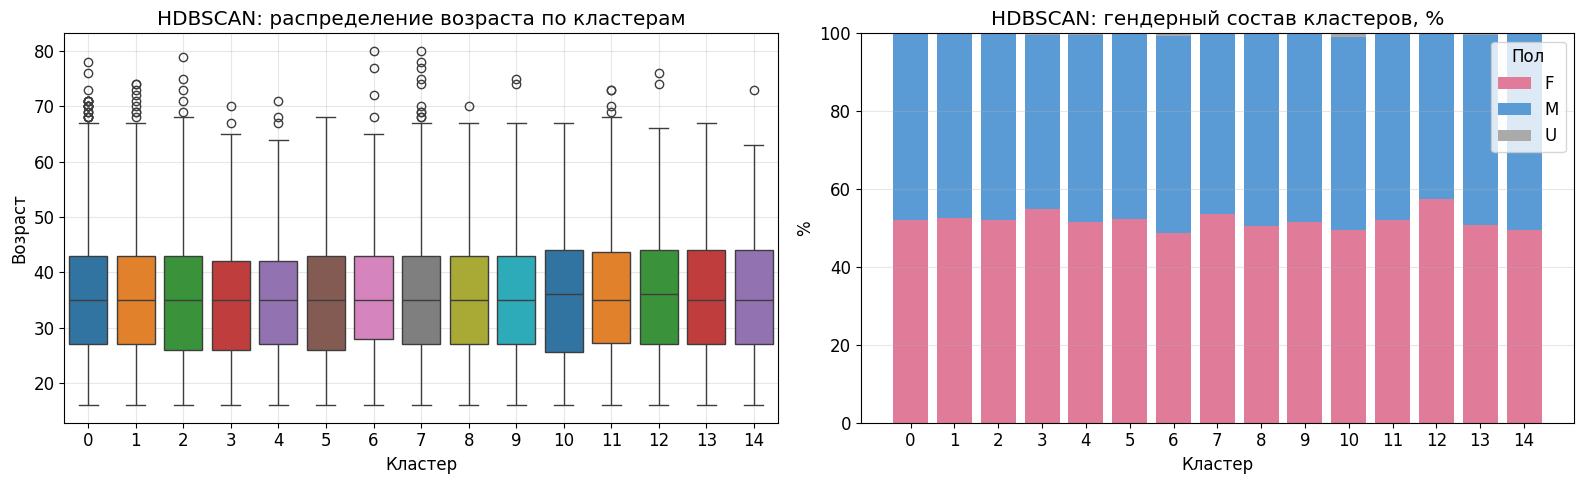

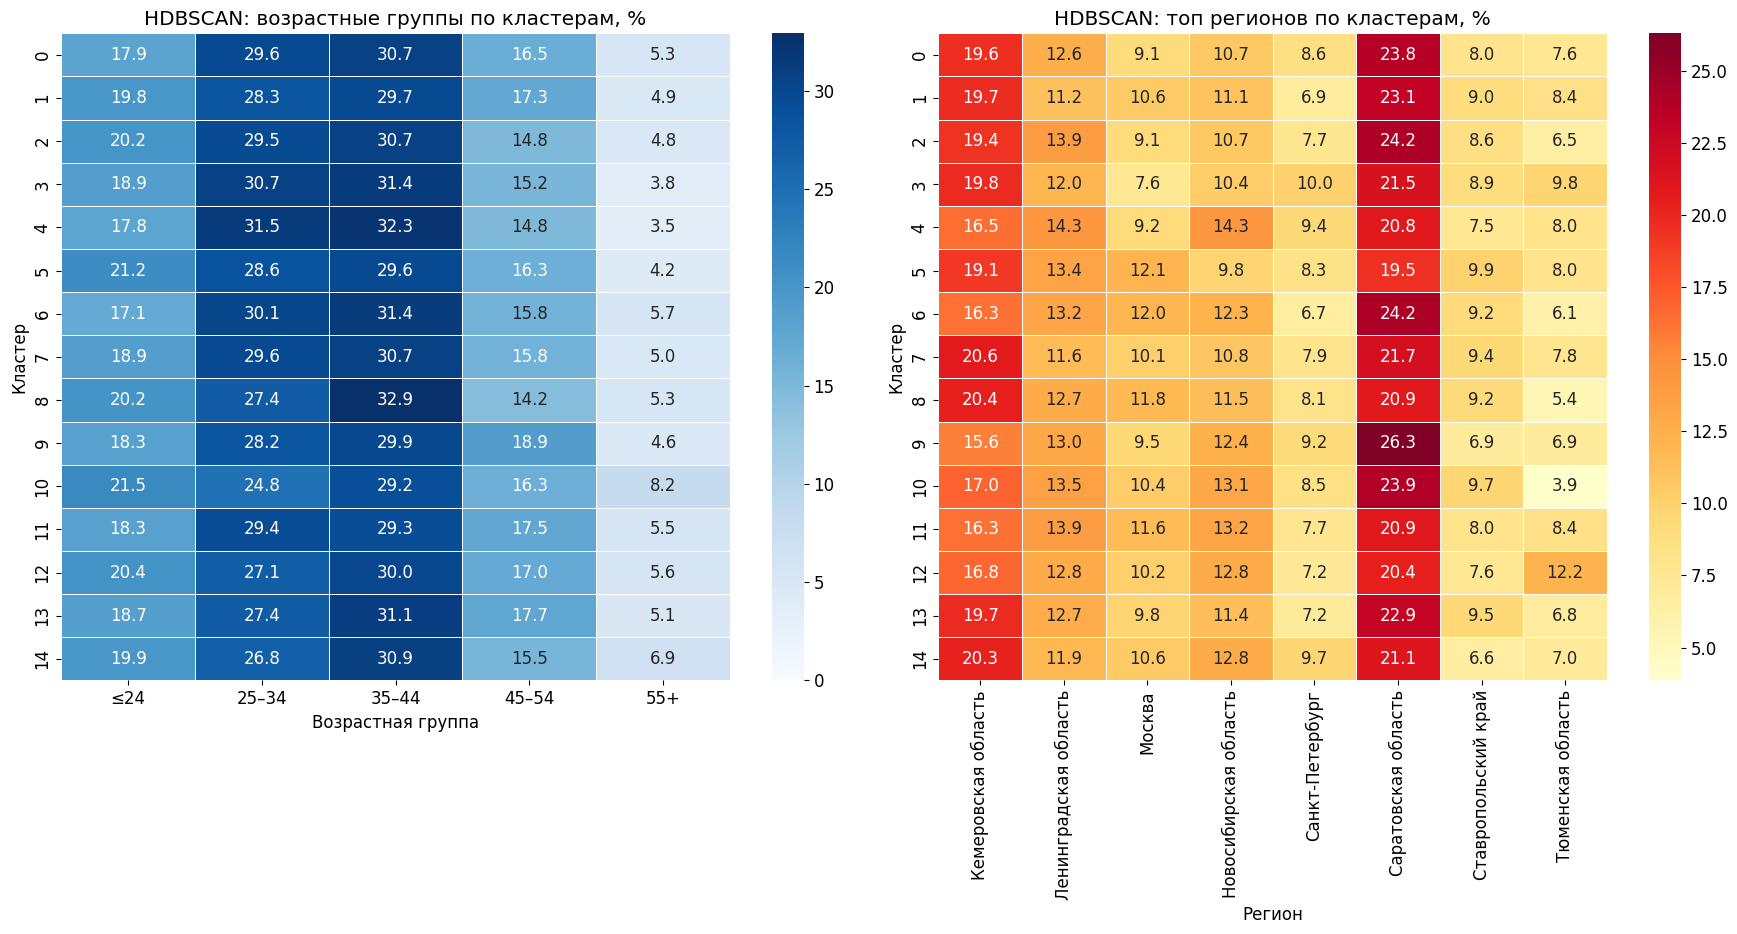

In [136]:
# ── Демографические профили кластеров HDBSCAN ────────────────────────────────
if 'cluster_hdbscan' not in pivot.columns:
    print("Колонка 'cluster_hdbscan' не найдена — запустите ячейку HDBSCAN выше.")
else:
    clients_demo_hdb = clients.rename(columns={'id': 'client_id'})[
        ['client_id', 'age', 'gender', 'region_id']
    ].copy()
    clients_demo_hdb['gender'] = clients_demo_hdb['gender'].fillna('U')

    cluster_demo_hdb = (
        pivot[['cluster_hdbscan']]
        .reset_index()
        .merge(clients_demo_hdb, on='client_id', how='left')
        .merge(regions.rename(columns={'id': 'region_id', 'name': 'region_name'}),
               on='region_id', how='left')
    )
    cluster_demo_hdb['age'] = cluster_demo_hdb['age'].fillna(cluster_demo_hdb['age'].median())

    # Отфильтровываем шум (-1)
    cluster_demo_hdb = cluster_demo_hdb[cluster_demo_hdb['cluster_hdbscan'] != -1].copy()
    order_hdb = sorted(cluster_demo_hdb['cluster_hdbscan'].unique())
    n_cl_hdb  = len(order_hdb)
    palette_hdb = sns.color_palette('tab10', n_colors=n_cl_hdb)

    # ── 1. Сводная таблица ──────────────────────────────────────────────────
    summary_hdb = []
    for cl in order_hdb:
        sub = cluster_demo_hdb[cluster_demo_hdb['cluster_hdbscan'] == cl]
        top_region = sub['region_name'].value_counts().idxmax() if sub['region_name'].notna().any() else '—'
        summary_hdb.append({
            'Кластер':              cl,
            'Абонентов':            len(sub),
            'Возраст (медиана)':    sub['age'].median(),
            'Возраст (mean±std)':   f"{sub['age'].mean():.1f} ± {sub['age'].std():.1f}",
            'Женщины, %':           f"{(sub['gender']=='F').mean()*100:.1f}",
            'Мужчины, %':           f"{(sub['gender']=='M').mean()*100:.1f}",
            'Топ-регион':           top_region,
        })
    print("── Сводная таблица демографии HDBSCAN-кластеров ──")
    display(pd.DataFrame(summary_hdb).set_index('Кластер'))

    # ── 2. Box plot возраста + stacked bar пола ──────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    sns.boxplot(
        data=cluster_demo_hdb, x='cluster_hdbscan', y='age',
        order=order_hdb, palette=palette_hdb, ax=axes[0]
    )
    axes[0].set_title('HDBSCAN: распределение возраста по кластерам')
    axes[0].set_xlabel('Кластер')
    axes[0].set_ylabel('Возраст')
    axes[0].grid(True, alpha=0.3)

    gender_hdb = (
        cluster_demo_hdb.groupby(['cluster_hdbscan', 'gender'])
        .size()
        .unstack(fill_value=0)
        .reindex(order_hdb)
    )
    gender_pct_hdb = gender_hdb.div(gender_hdb.sum(axis=1), axis=0) * 100
    gender_colors  = {'F': '#e07b9a', 'M': '#5b9bd5', 'U': '#aaaaaa'}
    bottom_hdb = pd.Series(0, index=gender_pct_hdb.index)
    for g in gender_pct_hdb.columns:
        axes[1].bar(
            gender_pct_hdb.index.astype(str),
            gender_pct_hdb[g],
            bottom=bottom_hdb,
            label=g,
            color=gender_colors.get(g, '#cccccc')
        )
        bottom_hdb = bottom_hdb + gender_pct_hdb[g]
    axes[1].set_title('HDBSCAN: гендерный состав кластеров, %')
    axes[1].set_xlabel('Кластер')
    axes[1].set_ylabel('%')
    axes[1].legend(title='Пол')
    axes[1].grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

    # ── 3. Возрастные группы × кластер (heatmap долей) ──────────────────────
    age_bins_hdb   = [0, 24, 34, 44, 54, 120]
    age_labels_hdb = ['≤24', '25–34', '35–44', '45–54', '55+']
    cluster_demo_hdb['age_group'] = pd.cut(
        cluster_demo_hdb['age'], bins=age_bins_hdb, labels=age_labels_hdb, right=True
    )
    age_hdb = (
        cluster_demo_hdb.groupby(['cluster_hdbscan', 'age_group'], observed=True)
        .size()
        .unstack(fill_value=0)
        .reindex(order_hdb)
    )
    age_hdb_pct = age_hdb.div(age_hdb.sum(axis=1), axis=0) * 100

    fig, axes = plt.subplots(1, 2, figsize=(18, max(4, n_cl_hdb * 0.5 + 2)))

    sns.heatmap(
        age_hdb_pct, cmap='Blues', annot=True, fmt='.1f',
        linewidths=0.5, vmin=0, ax=axes[0]
    )
    axes[0].set_title('HDBSCAN: возрастные группы по кластерам, %')
    axes[0].set_xlabel('Возрастная группа')
    axes[0].set_ylabel('Кластер')

    # ── 4. Топ регионов × кластер ───────────────────────────────────────────
    top_regions_hdb = (
        cluster_demo_hdb['region_name'].value_counts().head(8).index
    )
    region_hdb = (
        cluster_demo_hdb[cluster_demo_hdb['region_name'].isin(top_regions_hdb)]
        .groupby(['cluster_hdbscan', 'region_name'])
        .size()
        .unstack(fill_value=0)
        .reindex(order_hdb)
    )
    region_hdb_pct = region_hdb.div(region_hdb.sum(axis=1), axis=0) * 100
    sns.heatmap(
        region_hdb_pct, cmap='YlOrRd', annot=True, fmt='.1f',
        linewidths=0.5, ax=axes[1]
    )
    axes[1].set_title('HDBSCAN: топ регионов по кластерам, %')
    axes[1].set_xlabel('Регион')
    axes[1].set_ylabel('Кластер')
    plt.tight_layout()
    plt.show()


=== HDBSCAN диагностика ===
Размеры кластеров:


label
-1     13170
 0      6285
 1      1903
 2      2262
 3       652
 4       600
 5       877
 6       475
 7      2040
 8       881
 9       475
 10      367
 11     1390
 12      447
 13     1305
 14      317
Name: count, dtype: int64

Кластеров (без шума): 15
Доля шума (-1): 39.4%
Silhouette: 0.0233
Calinski-Harabasz: 312.21
Davies-Bouldin: 3.6665

Расстояния между центроидами (euclidean):


label,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
label,,,,,,,,,,,,,,,
0,0.0000,0.0887,0.1028,0.1088,0.1234,0.1168,0.1141,0.1050,0.1202,0.1136,0.1120,0.1094,0.1344,0.1217,0.1291
1,0.0887,0.0000,0.1017,0.1211,0.1177,0.1112,0.1300,0.1109,0.1131,0.1225,0.0859,0.1156,0.1289,0.1091,0.1220
2,0.1028,0.1017,0.0000,0.0808,0.1257,0.1220,0.1428,0.1266,0.1241,0.0801,0.1374,0.1278,0.1350,0.1161,0.1325
3,0.1088,0.1211,0.0808,0.0000,0.1466,0.1396,0.1063,0.0784,0.1445,0.1107,0.1506,0.1442,0.1513,0.1402,0.1505
4,0.1234,0.1177,0.1257,0.1466,0.0000,0.1313,0.1494,0.1284,0.1325,0.1451,0.1483,0.1257,0.1348,0.1016,0.1282
5,0.1168,0.1112,0.1220,0.1396,0.1313,0.0000,0.1421,0.1266,0.1367,0.1433,0.1410,0.1267,0.1386,0.1135,0.1366
6,0.1141,0.1300,0.1428,0.1063,0.1494,0.1421,0.0000,0.0798,0.1522,0.1139,0.1044,0.0881,0.1547,0.1431,0.1555
7,0.1050,0.1109,0.1266,0.0784,0.1284,0.1266,0.0798,0.0000,0.1279,0.1447,0.1399,0.1300,0.1359,0.1175,0.1337
8,0.1202,0.1131,0.1241,0.1445,0.1325,0.1367,0.1522,0.1279,0.0000,0.1492,0.1485,0.1283,0.1455,0.1135,0.1361


Топ-12 отличающих признаков:


,between_cluster_std
Книги и канцелярия,0.037496
Медицина и аптеки,0.034281
Недвижимость,0.032607
Дом и сад,0.025095
Онлайн-кинотеатры,0.024734
Одежда,0.023796
Кафе и рестораны,0.023452
Фитнес,0.022494
Игры,0.022282
Новости и СМИ,0.017357


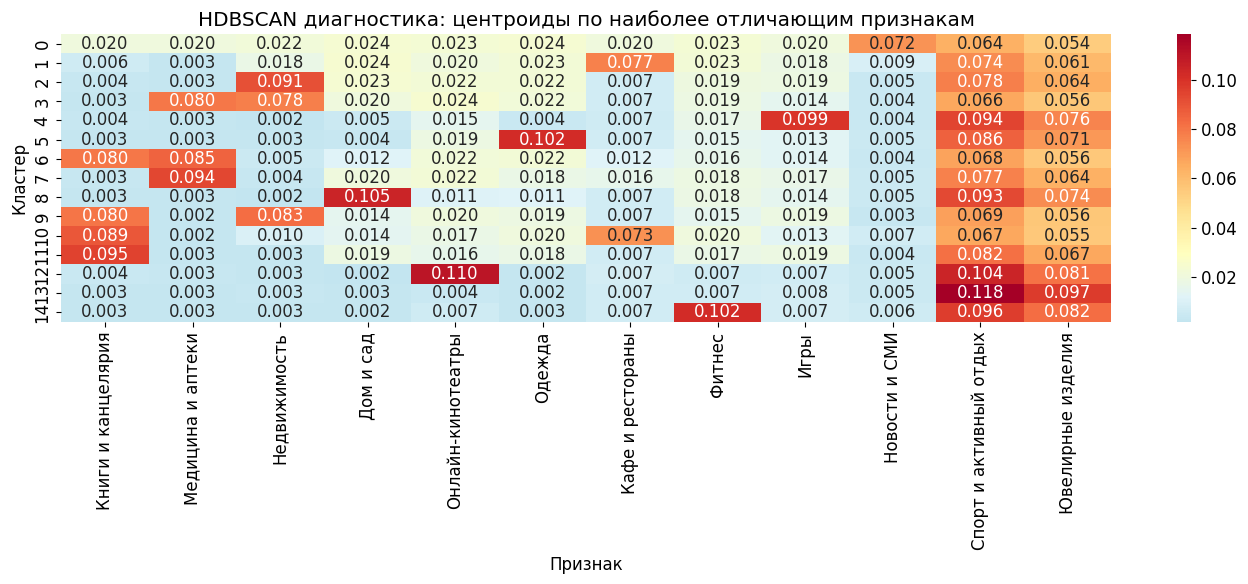

In [137]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics import pairwise_distances

# Берем только числовые признаки интересов (исключая колонки с метками кластеров)
feature_cols_diag = [
    c for c in pivot.columns
    if c not in ['cluster', 'cluster_hdbscan'] and np.issubdtype(pivot[c].dtype, np.number)
]
X_diag = pivot[feature_cols_diag].copy()


def diagnose_clustering(X_df, labels, title, top_n=12):
    labels = pd.Series(labels, index=X_df.index, name='label')
    non_noise_mask = labels != -1

    print(f"\n=== {title} ===")
    print("Размеры кластеров:")
    display(labels.value_counts().sort_index())

    n_clusters = labels[non_noise_mask].nunique()
    noise_share = (~non_noise_mask).mean()
    print(f"Кластеров (без шума): {n_clusters}")
    print(f"Доля шума (-1): {noise_share:.1%}")

    # Метрики разделимости
    if n_clusters >= 2 and non_noise_mask.sum() > 2:
        X_eval = X_df.loc[non_noise_mask].values
        y_eval = labels.loc[non_noise_mask].values
        sil = silhouette_score(X_eval, y_eval)
        ch = calinski_harabasz_score(X_eval, y_eval)
        db = davies_bouldin_score(X_eval, y_eval)
        print(f"Silhouette: {sil:.4f}")
        print(f"Calinski-Harabasz: {ch:.2f}")
        print(f"Davies-Bouldin: {db:.4f}")
    else:
        print("Недостаточно кластеров для расчета метрик (нужно >= 2 без шума).")

    # Профили центроидов и расстояния между ними
    if n_clusters >= 2:
        centroids = X_df.loc[non_noise_mask].groupby(labels.loc[non_noise_mask]).mean()
        dist = pd.DataFrame(
            pairwise_distances(centroids.values, metric='euclidean'),
            index=centroids.index,
            columns=centroids.index
        )
        print("\nРасстояния между центроидами (euclidean):")
        display(dist.round(4))

        # Топ отличающих признаков: межкластерное std по центроидам
        feature_separation = centroids.std(axis=0).sort_values(ascending=False)
        top_features = feature_separation.head(top_n).index.tolist()

        print(f"Топ-{top_n} отличающих признаков:")
        display(feature_separation.head(top_n).to_frame('between_cluster_std'))

        plt.figure(figsize=(14, 6))
        sns.heatmap(centroids[top_features], cmap='RdYlBu_r', center=centroids[top_features].mean().mean(), annot=True, fmt='.3f')
        plt.title(f'{title}: центроиды по наиболее отличающим признакам')
        plt.xlabel('Признак')
        plt.ylabel('Кластер')
        plt.tight_layout()
        plt.show()
    else:
        print("Центроидные сравнения пропущены: найден < 2 кластеров.")

# Диагностика HDBSCAN (если есть)
if 'cluster_hdbscan' in pivot.columns:
    diagnose_clustering(X_diag, pivot['cluster_hdbscan'].values, 'HDBSCAN диагностика')
else:
    print("Колонка 'cluster_hdbscan' не найдена — пропускаю HDBSCAN диагностику.")